<!-- reader-content -->

# Chip transformations

Transformations return new chips and leave the source declaration unchanged.
Start by changing one number on an isolated copy. Then remove structure,
partition independent components, and validate a schedule-aware reduction
against full dynamics.

## Rebind, clone, and serialize

`with_params()` is the smallest chip transformation. It changes numerical
parameters on an isolated copy. `clone()` copies the full structure, while
`to_dict()` and `Chip.from_dict()` provide a JSON-safe round trip for declared
devices, couplings, control equipment, baths, frames, and approximations.
Backends and computed results are runtime choices and are not serialized.

In [1]:
from quchip import Chip, DuffingTransmon

q = DuffingTransmon(freq=5.0, anharmonicity=-0.25, levels=3, label="q")
chip = Chip([q], frame="rotating")

rebound = chip.with_params({"q.freq": 5.10})
cloned = chip.clone()
restored = Chip.from_dict(chip.to_dict())

{
    "source_q_freq_ghz": chip.parameters["q.freq"],
    "rebound_q_freq_ghz": rebound.parameters["q.freq"],
    "source_dressed_q_ghz": float(chip.freq("q")),
    "rebound_dressed_q_ghz": float(rebound.freq("q")),
    "clone_is_distinct": cloned is not chip,
    "restored_devices": tuple(device.label for device in restored.devices),
    "round_trip_parameters_match": dict(restored.parameters) == dict(chip.parameters),
}

{'source_q_freq_ghz': 5.0,
 'rebound_q_freq_ghz': 5.1,
 'source_dressed_q_ghz': 5.0,
 'rebound_dressed_q_ghz': 5.1,
 'clone_is_distinct': True,
 'restored_devices': ('q',),
 'round_trip_parameters_match': True}

<!-- executed-output:start -->

Output:

```text
{'source_q_freq_ghz': 5.0,
 'rebound_q_freq_ghz': 5.1,
 'source_dressed_q_ghz': 5.0,
 'rebound_dressed_q_ghz': 5.1,
 'clone_is_distinct': True,
 'restored_devices': ('q',),
 'round_trip_parameters_match': True}
```

<!-- executed-output:end -->

## Eliminate a device

A far-detuned bus can be folded into its neighbours. The result owns an
ordinary reduced `Chip`, derived parameters, a validity record, notes, and a
plain-text report. The source chip is unchanged.

`method="sw"` uses a second-order Schrieffer-Wolff reduction.
`method="exact"` diagonalizes the same resolved static model and extracts the
kept block. Within the perturbative regime, their agreement checks the
second-order reduction against the exact kept block.

In [2]:
from quchip import RWA, Capacitive, Resonator, eliminate

left = DuffingTransmon(freq=5.0, anharmonicity=-0.25, levels=3, label="left")
right = DuffingTransmon(freq=5.2, anharmonicity=-0.24, levels=3, label="right")
bus = Resonator(freq=6.3, levels=4, label="bus")
bridge = Chip(
    [left, right, bus],
    [
        Capacitive(left, bus, g=0.08, label="left-bus"),
        Capacitive(right, bus, g=0.08, label="right-bus"),
    ],
    frame="rotating",
    approximation=RWA(),
)

sw_fold = eliminate(bridge, bus, method="sw")
exact_fold = eliminate(bridge, bus, method="exact")

fold_comparison = {
    label: {
        "full_dressed_ghz": float(bridge.freq(label)),
        "sw_reduced_ghz": float(sw_fold.chip.freq(label)),
        "exact_reduced_ghz": float(exact_fold.chip.freq(label)),
    }
    for label in ("left", "right")
}

{
    "before_devices": tuple(device.label for device in bridge.devices),
    "after_devices": tuple(device.label for device in sw_fold.chip.devices),
    "after_couplings": tuple(coupling.label for coupling in sw_fold.chip.couplings),
    "validity": sw_fold.validity,
    "frequencies": fold_comparison,
}

{'before_devices': ('left', 'right', 'bus'),
 'after_devices': ('left', 'right'),
 'after_couplings': ('elim_bus',),
 'validity': {'left-bus': {'g_over_delta': 0.06153846153846155,
   'is_valid': True,
   'min_block_gap': Array(1.1, dtype=float64)},
  'right-bus': {'g_over_delta': 0.07272727272727275,
   'is_valid': True,
   'min_block_gap': Array(1.1, dtype=float64)}},
 'frequencies': {'left': {'full_dressed_ghz': 4.994350606947265,
   'sw_reduced_ghz': 4.99492918831978,
   'exact_reduced_ghz': 4.994173483876981},
  'right': {'full_dressed_ghz': 5.193827649660221,
   'sw_reduced_ghz': 5.194323612393415,
   'exact_reduced_ghz': 5.193997635639327}}}

<!-- executed-output:start -->

Output:

```text
{'before_devices': ('left', 'right', 'bus'),
 'after_devices': ('left', 'right'),
 'after_couplings': ('elim_bus',),
 'validity': {'left-bus': {'g_over_delta': 0.06153846153846155,
   'is_valid': True,
   'min_block_gap': Array(1.1, dtype=float64)},
  'right-bus': {'g_over_delta': 0.07272727272727275,
   'is_valid': True,
   'min_block_gap': Array(1.1, dtype=float64)}},
 'frequencies': {'left': {'full_dressed_ghz': 4.994350606947265,
   'sw_reduced_ghz': 4.99492918831978,
   'exact_reduced_ghz': 4.994173483876981},
  'right': {'full_dressed_ghz': 5.193827649660221,
   'sw_reduced_ghz': 5.194323612393415,
   'exact_reduced_ghz': 5.193997635639327}}}
```

<!-- executed-output:end -->

Eliminating a device removes that mode. Eliminating a coupling keeps both
endpoints and replaces an exchange edge with its diagonal dispersive effect.
When a shipped retargeting rule applies, control lines move to the effective
device or edge and retain their labels. If a line would be stranded, the
transformation raises instead of silently dropping the control.

In [3]:
dq = DuffingTransmon(freq=5.0, anharmonicity=-0.25, levels=4, label="dq")
dr = Resonator(freq=7.0, levels=5, label="dr")
dispersive_edge = eliminate(
    Chip([dq, dr], [Capacitive(dq, dr, g=0.05, label="dq-dr")]),
    "dq-dr",
)

{
    "surviving_devices": tuple(device.label for device in dispersive_edge.chip.devices),
    "effective_coupling_type": type(dispersive_edge.chip.couplings[0]).__name__,
    "notes": tuple(dispersive_edge.notes),
}

{'surviving_devices': ('dq', 'dr'),
 'effective_coupling_type': 'CrossKerr',
 'notes': ("Coupling elimination: 'dq-dr' replaced by CrossKerr('elim_dq-dr') carrying the dressed pull chi = E11 - E10 - E01 + E00 (uniform-chi approximation; per-level chi differences and dispersive breakdown are not represented).",
  'Both endpoint devices survive with Lamb-shifted freq; control equipment passes through unchanged (no device was removed).')}

<!-- executed-output:start -->

Output:

```text
{'surviving_devices': ('dq', 'dr'),
 'effective_coupling_type': 'CrossKerr',
 'notes': ("Coupling elimination: 'dq-dr' replaced by CrossKerr('elim_dq-dr') carrying the dressed pull chi = E11 - E10 - E01 + E00 (uniform-chi approximation; per-level chi differences and dispersive breakdown are not represented).",
  'Both endpoint devices survive with Lamb-shifted freq; control equipment passes through unchanged (no device was removed).')}
```

<!-- executed-output:end -->

## Partition independent components

`partition()` is exact. It separates connected components that do not share a
coupling, non-separable bath, or drive crosstalk. Simulation uses this path
automatically when the initial state permits it; call it directly to inspect
or orchestrate the component solves.

In [4]:
island_qubits = [
    DuffingTransmon(freq=5.0 + 0.2 * index, anharmonicity=-0.25, levels=3, label=f"i{index}")
    for index in range(3)
]
islands = Chip(
    island_qubits,
    [Capacitive(island_qubits[0], island_qubits[1], g=0.005, label="i01")],
)
partition = islands.partition()

{
    "is_trivial": partition.is_trivial,
    "components": tuple(component.labels for component in partition),
    "owner_of_i2": partition.owner_of("i2"),
}

{'is_trivial': False, 'components': (('i0', 'i1'), ('i2',)), 'owner_of_i2': 1}

<!-- executed-output:start -->

Output:

```text
{'is_trivial': False, 'components': (('i0', 'i1'), ('i2',)), 'owner_of_i2': 1}
```

<!-- executed-output:end -->

## Validate a larger active patch

A Gaussian pulse drives one end of a four-transmon chain. `active_patch()`
keeps the driven neighbourhood, folds the two external spectators into the
surviving chip, and returns the same schedule bound to the reduced model.

The next model has 81 states and reduces to 9, so the full comparison remains
quick to rerun.

The reduction is approximate, so the result includes validity metrics. We use
those metrics before comparing the full and reduced dynamics.

In [5]:
import json

import matplotlib.pyplot as plt
import numpy as np

from quchip import RWA, Capacitive, ChargeDrive, Chip, DuffingTransmon, Gaussian, QuantumSequence

frequencies = (5.00, 5.35, 5.70, 6.05)
coupling_strength = 0.012

qubits = [
    DuffingTransmon(
        freq=frequency,
        anharmonicity=-0.25,
        levels=3,
        label=f"q{index}",
    )
    for index, frequency in enumerate(frequencies)
]
couplings = [
    Capacitive(
        qubits[index],
        qubits[index + 1],
        g=coupling_strength,
        label=f"c{index}{index + 1}",
    )
    for index in range(3)
]
chip = Chip(
    qubits,
    couplings=couplings,
    frame="rotating",
    approximation=RWA(),
)

drive = ChargeDrive(qubits[0], label="q0-charge")
chip.wire(drive)

sequence = QuantumSequence(chip)
_ = sequence.schedule(
    drive,
    envelope=Gaussian(duration=20.0, sigmas=3.0, amplitude=0.04),
    freq=chip.freq(qubits[0]),
)

## Keep the scheduled neighbourhood

The pulse targets `q0`. With `hops=1`, the active patch also keeps its direct
neighbour `q1`; `q2` and `q3` are folded away from the far end inward.

The interactive topology plots require the optional `quchip[viz]` extra. They
use dressed frequencies and full-pull cross-Kerr values; omit
`values="dressed"` for the cheaper bare declaration view.

In [6]:
patch = sequence.active_patch(hops=1, method="sw")

full_dimension = int(np.prod(chip.dims))
reduced_dimension = int(np.prod(patch.chip.dims))
same_schedule = sequence.settings["entries"] == patch.sequence.settings["entries"]

full_topology_path = "../docs/_static/active-patch-full.html"
reduced_topology_path = "../docs/_static/active-patch-reduced.html"
chip.plot_graph(
    full_topology_path,
    full=False,
    values="dressed",
    layout="hierarchical",
    height="360px",
)
patch.chip.plot_graph(
    reduced_topology_path,
    full=False,
    values="dressed",
    layout="hierarchical",
    height="360px",
)

{
    "full_topology": full_topology_path,
    "reduced_topology": reduced_topology_path,
    "full_dimension": full_dimension,
    "reduced_dimension": reduced_dimension,
}

{'full_topology': '../docs/_static/active-patch-full.html',
 'reduced_topology': '../docs/_static/active-patch-reduced.html',
 'full_dimension': 81,
 'reduced_dimension': 9}

<!-- executed-output:start -->

Output:

```text
{'full_topology': '../docs/_static/active-patch-full.html',
 'reduced_topology': '../docs/_static/active-patch-reduced.html',
 'full_dimension': 81,
 'reduced_dimension': 9}
```

<!-- executed-output:end -->

```{raw} html
<div class="quchip-topology-grid">
  <figure>
    <figcaption>Full four-device chain</figcaption>
    <iframe src="../_static/active-patch-full.html" title="Interactive full chip topology" loading="lazy"></iframe>
  </figure>
  <figure>
    <figcaption>Two-device active patch</figcaption>
    <iframe src="../_static/active-patch-reduced.html" title="Interactive reduced chip topology" loading="lazy"></iframe>
  </figure>
</div>
```

Drag a node to inspect either topology. Couplings are explicit junction nodes;
the reduced graph keeps `q0`, `q1`, and their coupling while spectator effects
are folded into the returned parameters.

## See what the fold changed

The two graphs should look similar: the reduction is meant to preserve the
dressed physics of the retained devices. The parameter correction is easier to
see when declared values and dressed observables are kept separate. Model
values are shown in MHz and patch-minus-full differences in kHz.

In [7]:
from IPython.display import Markdown, display

full_kerr = chip.kerr_matrix()
patch_kerr = patch.chip.kerr_matrix()
comparison_rows = [
    ("declared q1.freq", chip["q1"].freq, patch.chip["q1"].freq),
    ("dressed f01(q0)", chip.freq("q0"), patch.chip.freq("q0")),
    ("dressed f01(q1)", chip.freq("q1"), patch.chip.freq("q1")),
    ("full-pull K(q0, q1)", full_kerr["q0", "q1"], patch_kerr["q0", "q1"]),
    (
        "declared c01.g",
        chip.coupling("c01").coupling_strength,
        patch.chip.coupling("c01").coupling_strength,
    ),
]
comparison_table = "\n".join([
    "| Quantity | Full model (MHz) | Active patch (MHz) | Patch - full (kHz) |",
    "|---|---:|---:|---:|",
    *(
        f"| {name} | {float(full) * 1e3:.6f} | {float(reduced) * 1e3:.6f} "
        f"| {(float(reduced) - float(full)) * 1e6:+.3f} |"
        for name, full, reduced in comparison_rows
    ),
])
display(Markdown(comparison_table))

| Quantity | Full model (MHz) | Active patch (MHz) | Patch - full (kHz) |
|---|---:|---:|---:|
| declared q1.freq | 5350.000000 | 5349.588087 | -411.913 |
| dressed f01(q0) | 4999.574175 | 4999.573966 | -0.208 |
| dressed f01(q1) | 5349.971555 | 5349.984916 | +13.361 |
| full-pull K(q0, q1) | -2.332233 | -2.343413 | -11.180 |
| declared c01.g | 12.000000 | 12.000000 | +0.000 |

<!-- executed-output:start -->

Output:

| Quantity | Full model (MHz) | Active patch (MHz) | Patch - full (kHz) |
|---|---:|---:|---:|
| declared q1.freq | 5350.000000 | 5349.588087 | -411.913 |
| dressed f01(q0) | 4999.574175 | 4999.573966 | -0.208 |
| dressed f01(q1) | 5349.971555 | 5349.984916 | +13.361 |
| full-pull K(q0, q1) | -2.332233 | -2.343413 | -11.180 |
| declared c01.g | 12.000000 | 12.000000 | +0.000 |

<!-- executed-output:end -->

The fold moves the retained `q1` declaration to absorb the spectators' Lamb
shift. The remaining dressed differences measure the approximation error. The
declared `c01` exchange stays fixed because each eliminated end-of-chain device
has only one surviving neighbour; there is no second survivor between which it
could mediate a new exchange.

The reduction result keeps the Schrieffer-Wolff validity record for every
fold. Every coupling ratio remains below the package's `0.1` validity boundary.

In [8]:
validity_records = [
    record
    for eliminated_device in patch.validity.values()
    for record in eliminated_device.values()
]
max_g_over_delta = max(float(record["g_over_delta"]) for record in validity_records)
minimum_block_gap = min(float(record["min_block_gap"]) for record in validity_records)
all_folds_valid = all(bool(record["is_valid"]) for record in validity_records)

patch.validity

{'q3': {'c23': {'g_over_delta': 0.03428571428571432,
   'is_valid': True,
   'min_block_gap': Array(0.35, dtype=float64)}},
 'q2': {'c12': {'g_over_delta': Array(0.03432606, dtype=float64),
   'is_valid': Array(True, dtype=bool),
   'min_block_gap': Array(0.34958857, dtype=float64)}}}

<!-- executed-output:start -->

Output:

```text
{'q3': {'c23': {'g_over_delta': 0.03428571428571432,
   'is_valid': True,
   'min_block_gap': Array(0.35, dtype=float64)}},
 'q2': {'c12': {'g_over_delta': Array(0.03432606, dtype=float64),
   'is_valid': Array(True, dtype=bool),
   'min_block_gap': Array(0.34958857, dtype=float64)}}}
```

<!-- executed-output:end -->

## Replay the schedule

Both simulations use the schedule declared above. `patch.simulate()` runs the
copy that `active_patch()` rebound to the reduced chip; there is no second
pulse declaration.

In [9]:
times = np.linspace(0.0, 40.0, 161)

full_result = sequence.simulate(tlist=times)
reduced_result = patch.simulate(tlist=times)

full_population = np.asarray(full_result.population("q0", level=1)).real
reduced_population = np.asarray(reduced_result.population("q0", level=1)).real
population_residual = np.abs(full_population - reduced_population)

The leading reduction error at the retained/eliminated boundary scales as
$(g/\Delta)^2$. A factor of 5 leaves headroom for multilevel and finite-pulse
effects without choosing the tolerance from the observed residual.

In [10]:
boundary_detuning = abs(float(chip.freq("q2")) - float(chip.freq("q1")))
boundary_ratio = coupling_strength / boundary_detuning
residual_tolerance = 5.0 * boundary_ratio**2
maximum_residual = float(np.max(population_residual))

if not all_folds_valid:
    raise RuntimeError("The active patch contains an invalid elimination step.")
if maximum_residual >= residual_tolerance:
    raise RuntimeError("The reduced dynamics exceed the validity-derived tolerance.")
if not same_schedule:
    raise RuntimeError("The reduced sequence does not preserve the scheduled entries.")
if tuple(device.label for device in chip.devices) != ("q0", "q1", "q2", "q3"):
    raise RuntimeError("active_patch() mutated the original chip.")

## Compare full and reduced dynamics

The upper panel overlays the driven-qubit population. The logarithmic lower
panel plots the residual; values below $10^{-10}$ are floored for display only.

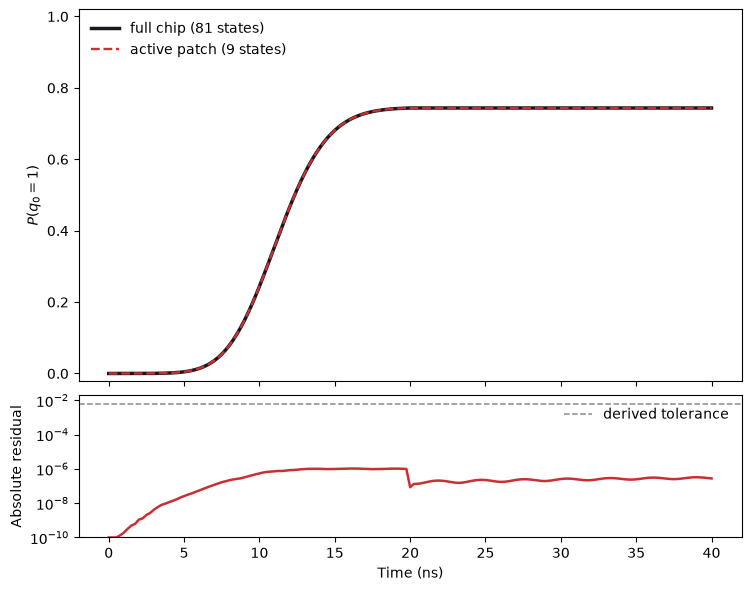

In [11]:
figure, (population_axis, residual_axis) = plt.subplots(
    2,
    1,
    figsize=(7.4, 5.8),
    height_ratios=(3.0, 1.15),
    sharex=True,
    layout="constrained",
)

population_axis.plot(times, full_population, color="#16181C", linewidth=2.5, label="full chip (81 states)")
population_axis.plot(
    times,
    reduced_population,
    color="#C92F33",
    linewidth=1.7,
    linestyle="--",
    label="active patch (9 states)",
)
population_axis.set_ylabel(r"$P(q_0=1)$")
population_axis.set_ylim(-0.02, 1.02)
population_axis.legend(frameon=False, loc="upper left")

display_residual = np.maximum(population_residual, 1.0e-10)
residual_axis.semilogy(times, display_residual, color="#C92F33", linewidth=1.8)
residual_axis.axhline(residual_tolerance, color="0.55", linestyle="--", linewidth=1.1, label="derived tolerance")
residual_axis.set(
    xlabel="Time (ns)",
    ylabel="Absolute residual",
    ylim=(1.0e-10, 2.0e-2),
)
residual_axis.legend(frameon=False, loc="upper right")

figure_path = "../docs/images/reduce_and_replay.png"
figure.savefig(figure_path, dpi=180)
plt.show()

```{figure} ../images/reduce_and_replay.png
:width: 720px
:alt: Full and active-patch driven-qubit populations with their absolute residual below

The same schedule runs on the 81-state chip and its 9-state active patch.
```

The receipt records both the approximation's own validity and the independent
forward comparison.

In [12]:
reduction_receipt = {
    "active_labels": list(patch.active_labels),
    "all_folds_valid": all_folds_valid,
    "eliminated_labels": list(patch.eliminated_labels),
    "figure": figure_path,
    "full_dimension": full_dimension,
    "maximum_population_residual": maximum_residual,
    "maximum_g_over_delta": max_g_over_delta,
    "minimum_block_gap_ghz": minimum_block_gap,
    "original_chip_unchanged": tuple(device.label for device in chip.devices) == ("q0", "q1", "q2", "q3"),
    "peak_full_population": float(np.max(full_population)),
    "reduced_dimension": reduced_dimension,
    "reduction_method": "sw",
    "residual_tolerance": residual_tolerance,
    "same_schedule": same_schedule,
}

print(f"RESULT reduction={json.dumps(reduction_receipt, sort_keys=True, separators=(',', ':'))}")

RESULT reduction={"active_labels":["q0","q1"],"all_folds_valid":true,"eliminated_labels":["q3","q2"],"figure":"../docs/images/reduce_and_replay.png","full_dimension":81,"maximum_g_over_delta":0.03432606492529982,"maximum_population_residual":1.0533077150487458e-06,"minimum_block_gap_ghz":0.3495885714285727,"original_chip_unchanged":true,"peak_full_population":0.7436566856768277,"reduced_dimension":9,"reduction_method":"sw","residual_tolerance":0.0058774739885992825,"same_schedule":true}


<!-- executed-output:start -->

Output:

```text
RESULT reduction={"active_labels":["q0","q1"],"all_folds_valid":true,"eliminated_labels":["q3","q2"],"figure":"../docs/images/reduce_and_replay.png","full_dimension":81,"maximum_g_over_delta":0.03432606492529982,"maximum_population_residual":1.0533077150487458e-06,"minimum_block_gap_ghz":0.3495885714285727,"original_chip_unchanged":true,"peak_full_population":0.7436566856768277,"reduced_dimension":9,"reduction_method":"sw","residual_tolerance":0.05877473988599283,"same_schedule":true}
```

<!-- executed-output:end -->

Change `hops` to choose how much of the coupling neighbourhood remains
explicit. Change the spectator detunings or couplings and read the returned
validity record before trusting the smaller model.

Choose a transformation by the question. Use `with_params()` for new numbers
on the same structure, `partition()` for exact independent components,
`eliminate()` for a physical effective model, and `active_patch()` when the
scheduled experiment should choose the retained neighbourhood. Keep the
result object until you have inspected its notes, validity, and an observable
that matters for the next calculation.